# Final Project Notebook

**Project Title:** [Your Project Title]  
**Team Members:** Kelly Zhou, Paula Martinez, Sankaranarayanan Krishnamoorthy  
**Course:** DX703, Spring 2026  
**Date:** 04-27-2026  

This notebook presents our final machine learning pipeline, including finalized preprocessing, final model retraining, and evaluation on a held-out test set.

# A.1: Setup and Context

## A.1.1 Project Overview
Provide a brief, clear overview of the project context and the work leading to this final model.

Summary of Milestones 1 and 2:

A short Markdown overview describing major steps we took previosuly, including:

- Data cleaning and preprocessing
- Feature engineering or augmentation strategies
- Early model experiments in Milestone 2 and what we learned from them.

Final preprocessing pipeline:

Include all finalized code for:

- Loading the dataset
- Cleaning steps (text normalization, image transforms, etc.)
- Preprocessing (tokenization, resizing, normalization, augmentation, etc.)
- This is your opportunity to refine or simplify any parts of your earlier pipeline based on what you learned in Milestone 2.

## A.1.2 Imports and Global Settings

Import packages, set random seeds, define constants, and configure any plotting or runtime settings.

In [2]:
# Imports
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# --- Standard Libraries
import os
import time
import math
import random
from collections import Counter

# --- Core Data / Numerics
import numpy as np
import pandas as pd

# --- Visualization
import matplotlib.pyplot as plt
# import seaborn as sns              # optional
import matplotlib.ticker as mticker  # optional (for formatted axes)

# --- NLP / Tokenization
import spacy                         # used for text preprocessing (HuffPost)

# --- Progress Tracking
from tqdm import tqdm                # optional (nice for loops)

from IPython.display import display

# --- TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import layers, models, Input, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, MaxPooling2D, Conv2D,
    SeparableConv2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization
)

# --- Additional Imports ---

from datasets import load_dataset, DatasetDict, Dataset
from datasets.features import ClassLabel
import pandas as pd
import numpy as np
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
from transformers import DistilBertForSequenceClassification
from time import time
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score

from tqdm import tqdm
from transformers import AutoTokenizer

from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, DistilBertForSequenceClassification
from sklearn.metrics import classification_report


# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)   # sets Python, NumPy, and TensorFlow seeds

# Utility: format seconds as HH:MM:SS

def format_hms(seconds: float) -> str:
    """Convert seconds to HH:MM:SS format."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## A.1.3 Data Loading

Explain where the dataset comes from and how the train, validation, and test data are loaded.

In [4]:
# Data Loading
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853


In [9]:
# Data Cleaning

# Combining title and description into a single text field
def combine_text(example):
    headline = example.get("headline") or ""
    desc = example.get("short_description") or ""
    return headline + " [SEP] " + desc

texts = [combine_text(ex) for ex in huff_all]
labels = [ex["category"] for ex in huff_all]

huffpost_df = pd.DataFrame({"text": texts,"category": labels})

print("Dataset shape:", huffpost_df.shape)

# Change rows to lowercase and remove whitespaces
huffpost_df["text"] = huffpost_df["text"].str.lower().str.strip()

# Check and remove empty rows or small rows with less than 20 characters
short_rows = huffpost_df[huffpost_df["text"].str.len() < 20]
print("Number of short rows:", len(short_rows))
huffpost_df = huffpost_df[huffpost_df["text"].str.len() > 20]

# Remove Duplicates
huffpost_df = huffpost_df.drop_duplicates(subset="text")

# Reset Index
huffpost_df = huffpost_df.reset_index(drop=True)

# View remaining samples
print("Remaining samples:", len(huffpost_df))


Dataset shape: (200853, 2)
Number of short rows: 148
Remaining samples: 200185



Top 10 classes (with %):
POLITICS: 32707 (16.34%)
WELLNESS: 17821 (8.90%)
ENTERTAINMENT: 16048 (8.02%)
TRAVEL: 9877 (4.93%)
STYLE & BEAUTY: 9511 (4.75%)
PARENTING: 8649 (4.32%)
HEALTHY LIVING: 6667 (3.33%)
QUEER VOICES: 6310 (3.15%)
FOOD & DRINK: 6225 (3.11%)
BUSINESS: 5928 (2.96%)

Total number of classes: 41


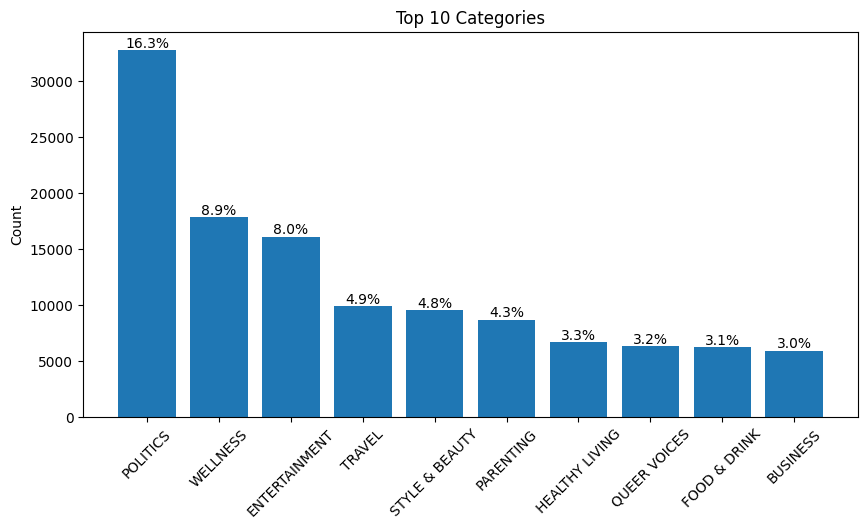


Text length statistics:
count    200185.000000
mean         30.298349
std          14.035833
min           3.000000
25%          21.000000
50%          29.000000
75%          36.000000
max         246.000000
Name: text_length, dtype: float64

Length percentiles (50,75,90,95): [29. 36. 50. 57.]


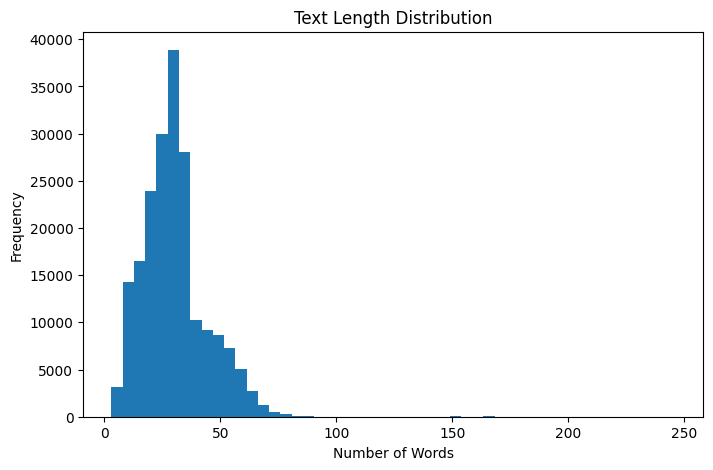

Chosen max_length (95th percentile): 57

=== SHORTEST TEXT ===
Length: 3
Category: COMEDY
Text:
 constitutional crossroads [sep]

=== LONGEST TEXT ===
Length: 246
Category: POLITICS
Text:
 sunday roundup [sep] this week the nation watched as the #nevertrump movement folded faster than one of the presumptive nominee's beachfront developments. as many tried to explain away trump's reckless, racist extremism, a few put principle over party. the wife of former republican senator bob bennett, who died on may 4, revealed that her husband spent his dying hours reaching out to muslims. "he would go to people with the hijab [on] and tell them he was glad they were in america," she told the daily beast. "he wanted to apologize on behalf of the republican party." in the u.k., prime minister david cameron called trump's proposal to ban muslims from entering the u.s., "divisive, stupid and wrong." trump's reply was that he didn't think he and cameron would "have a very good relationship." the press

In [17]:
# EDA

# Top Categories

class_counts = huffpost_df["category"].value_counts()

class_percent = (class_counts / class_counts.sum()) * 100

print("\nTop 10 classes (with %):")
for cat in class_counts.head(10).index:
    count = class_counts[cat]
    pct = class_percent[cat]
    print(f"{cat}: {count} ({pct:.2f}%)")

print("\nTotal number of classes:", huffpost_df["category"].nunique())

top10 = class_counts.head(10)
top10_pct = class_percent.head(10)

plt.figure(figsize=(10,5))
bars = plt.bar(top10.index, top10.values)

for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = top10_pct.iloc[i]
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{pct:.1f}%", ha='center', va='bottom')

plt.title("Top 10 Categories")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


# Examine text length
huffpost_df["text_length"] = huffpost_df["text"].apply(lambda x: len(x.split()))

print("\nText length statistics:")
print(huffpost_df["text_length"].describe())

percentiles = np.percentile(huffpost_df["text_length"], [50, 75, 90, 95])
print("\nLength percentiles (50,75,90,95):", percentiles)

plt.figure(figsize=(8,5))
plt.hist(huffpost_df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# Examine max length
max_length = int(np.percentile(huffpost_df["text_length"], 95))
print("Chosen max_length (95th percentile):", max_length)

# Examine shortest row
shortest_row = huffpost_df.loc[huffpost_df["text_length"].idxmin()]

print("\n=== SHORTEST TEXT ===")
print("Length:", shortest_row["text_length"])
print("Category:", shortest_row["category"])
print("Text:\n", shortest_row["text"])

# Examine longest row
longest_row = huffpost_df.loc[huffpost_df["text_length"].idxmax()]

print("\n=== LONGEST TEXT ===")
print("Length:", longest_row["text_length"])
print("Category:", longest_row["category"])
print("Text:\n", longest_row["text"])

## A.1.4 Final Preprocessing Pipeline

Describe the final preprocessing pipeline you decided to keep after Milestones 1 and 2.

Include things like:
- text cleaning / normalization
- tokenization or vectorization
- image resizing / normalization / augmentation
- label encoding
- helper functions for preprocessing

In [18]:
# Tokenization/Standardization w/distilBERT
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=max_length)

In [23]:
# Encode categorical variables
labels = sorted(huffpost_df["category"].unique())
label_2 = {label: i for i, label in enumerate(labels)}
labe_2_id = {i: label for label, i in label_2.items()}

huffpost_df["label"] = huffpost_df["category"].map(label_2)

# Check class distribution
label_counts = huffpost_df["label"].value_counts()
print("Number of Classes:", len(label_counts))
print("Sample Distribution", list(label_counts.items())[:10])

# Check class imbalance and define class weights
total = len(huffpost_df)
num_classes = len(label_counts)
class_weights = {
    label: total / (num_classes * count)
    for label, count in label_counts.items()}

print("Class Weights: ", class_weights)

# Check length variance
text_lengths = huffpost_df["text"].str.len()
print("Max length:", text_lengths.max())
print("Average length:", text_lengths.mean())


Number of Classes: 41
Sample Distribution [(24, 32707), (37, 17821), (10, 16048), (34, 9877), (30, 9511), (22, 8649), (16, 6667), (25, 6310), (13, 6225), (3, 5928)]
Class Weights:  {24: 0.1492818349469458, 37: 0.27397794599684394, 10: 0.3042473190185541, 34: 0.49433643572033575, 30: 0.5133593707927406, 22: 0.5645231790507291, 16: 0.7323475289650152, 25: 0.7737814541378377, 13: 0.7843471446762661, 3: 0.8236438892729008, 5: 0.9584925354553899, 28: 1.0005247900839664, 2: 1.079734846441786, 17: 1.1734104723887901, 23: 1.2532240697150299, 33: 1.3325766854830121, 35: 1.3373215490577255, 18: 1.4127780600722675, 8: 1.4268150133283917, 38: 1.4360473457675753, 6: 1.4360473457675753, 20: 1.7369480525114749, 36: 1.8321054317485013, 15: 1.8685652413355363, 40: 1.8990902277750898, 26: 1.917738010844366, 29: 2.1738917967986446, 27: 2.242793282319594, 39: 2.2438239777618363, 31: 2.3339201604253135, 32: 2.401653209842477, 21: 2.8619935378720727, 0: 3.2442265618669475, 14: 3.495032910243204, 12: 3.50255

In [24]:
# Train/Test Split 80/20/20

train_df, temp_df = train_test_split(
    huffpost_df,
    test_size=0.2,
    stratify=huffpost_df["label"],
    random_state=42)

#second split
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

#display sizes
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 160148
Validation size: 20018
Test size: 20019


## A.1.5 Processed Data / Sanity Checks

Use this section to confirm the preprocessing worked correctly.

In [25]:
#show processed examples
train_df[["text", "category"]].head()

,text,category
55803,russia's chances of competing in rio 2016 trac...,SPORTS
22704,find your breath while reporting in the age of...,MEDIA
105755,immigration fight is psychological warfare [se...,POLITICS
76745,the best jobs for work-life balance [sep] ever...,HEALTHY LIVING
165048,chronic stress raises diabetes risk [sep] the ...,WELLNESS


In [26]:
# convert splits to hugging face datasets
train_dataset = Dataset.from_pandas(train_df)
val_dataset   = Dataset.from_pandas(val_df)
test_dataset  = Dataset.from_pandas(test_df)

# apply tokenizer
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset   = val_dataset.map(tokenize_function, batched=True)
test_dataset  = test_dataset.map(tokenize_function, batched=True)

# set pytorch
columns_to_return = ["input_ids", "attention_mask", "label"]

train_dataset.set_format(type="torch", columns=columns_to_return)
val_dataset.set_format(type="torch", columns=columns_to_return)
test_dataset.set_format(type="torch", columns=columns_to_return)

Map:   0%|          | 0/160148 [00:00<?, ? examples/s]

Map:   0%|          | 0/20018 [00:00<?, ? examples/s]

Map:   0%|          | 0/20019 [00:00<?, ? examples/s]

# A.2: Model Selection and Retraining

In [31]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [28]:
#select pretrained architecture: BERT
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DB_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label_2)
).to(device)

optimizer = torch.optim.AdamW(DB_model.parameters(), lr=2e-5)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [33]:
#create training loop
EPOCHS = 3
patience = 5

all_preds = []
all_labels = []

best_val_loss = float("inf")
patience_counter = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

start_time = time()

for epoch in range(EPOCHS):
    DB_model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = DB_model(
            input_ids=input_ids,
            attention_mask=batch["attention_mask"].to(device),
            labels=labels)

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # validation
    DB_model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            outputs = DB_model(
                input_ids=input_ids,
                attention_mask=batch["attention_mask"].to(device),
                labels=labels)

            loss = outputs.loss
            logits = outputs.logits

            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            # store predictions + labels
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}:")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")

    # early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = DB_model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

end_time = time()
train_time_pt = end_time - start_time
print(f"\nTraining time: {(end_time - start_time):.2f} seconds")

Epoch 1:
Train Loss: 1.0086, Train Acc: 0.7068
Val Loss:   0.9801, Val Acc:   0.7061
Epoch 2:
Train Loss: 0.7788, Train Acc: 0.7657
Val Loss:   0.9845, Val Acc:   0.7108
Epoch 3:
Train Loss: 0.5964, Train Acc: 0.8175
Val Loss:   1.0271, Val Acc:   0.7099

Training time: 627.45 seconds


In [47]:
DB_model.load_state_dict(best_model_state)
DB_model.eval()

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [37]:

# print classification report

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))


Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.59      0.55       453
           1       0.56      0.50      0.53       402
           2       0.52      0.51      0.52      1356
           3       0.56      0.60      0.58      1779
           4       0.59      0.55      0.57       345
           5       0.63      0.52      0.57      1527
           6       0.62      0.65      0.64      1020
           7       0.69      0.47      0.56       309
           8       0.82      0.84      0.83      1026
           9       0.59      0.46      0.51       303
          10       0.74      0.81      0.78      4815
          11       0.60      0.55      0.57       396
          12       0.47      0.41      0.44       420
          13       0.76      0.84      0.80      1866
          14       0.44      0.27      0.34       420
          15       0.49      0.54      0.51       783
          16       0.60      0.48      0.53      1998
   

In [38]:
print(classification_report(all_labels, all_preds, target_names=labels))

                precision    recall  f1-score   support

          ARTS       0.52      0.59      0.55       453
ARTS & CULTURE       0.56      0.50      0.53       402
  BLACK VOICES       0.52      0.51      0.52      1356
      BUSINESS       0.56      0.60      0.58      1779
       COLLEGE       0.59      0.55      0.57       345
        COMEDY       0.63      0.52      0.57      1527
         CRIME       0.62      0.65      0.64      1020
CULTURE & ARTS       0.69      0.47      0.56       309
       DIVORCE       0.82      0.84      0.83      1026
     EDUCATION       0.59      0.46      0.51       303
 ENTERTAINMENT       0.74      0.81      0.78      4815
   ENVIRONMENT       0.60      0.55      0.57       396
         FIFTY       0.47      0.41      0.44       420
  FOOD & DRINK       0.76      0.84      0.80      1866
     GOOD NEWS       0.44      0.27      0.34       420
         GREEN       0.49      0.54      0.51       783
HEALTHY LIVING       0.60      0.48      0.53  

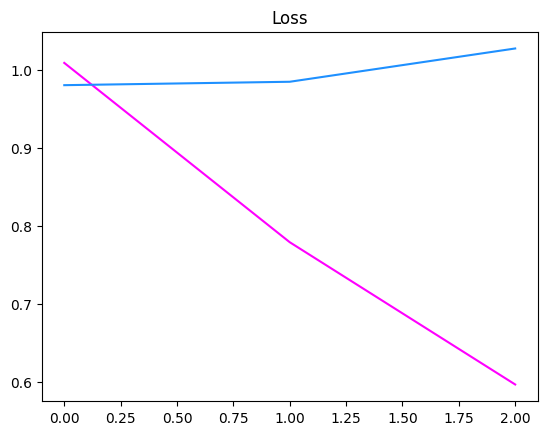

In [34]:
#plot loss
plt.plot(train_losses, label="Train Loss", color='fuchsia')
plt.plot(val_losses, label="Val Loss", color='dodgerblue')
plt.title('Loss')
#plt.legend(['Train', 'Validation'])
plt.show()

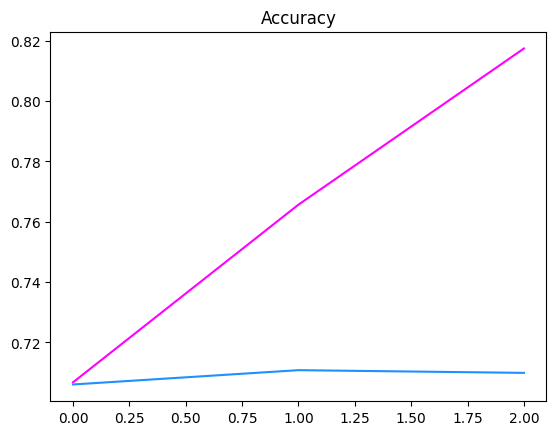

In [35]:
#plot accuracy
plt.plot(train_accs, label="Train Accuracy", color='fuchsia')
plt.plot(val_accs, label="Val Accuracy", color='dodgerblue')
plt.title('Accuracy')
#plt.legend(['Train', 'Validation'])
plt.show()

In [43]:
# Test Set
test_losses = []

test_preds = []
test_labels = []

test_loss, correct, total = 0, 0, 0

DB_model.eval()
test_loss_epoch = 0

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        outputs = DB_model(
            input_ids=input_ids,
            attention_mask=batch["attention_mask"].to(device),
            labels=labels
        )

        loss = outputs.loss
        test_loss_epoch += loss.item()
        logits = outputs.logits

        test_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_loss /= len(test_loader)
test_acc = correct / total
test_loss_epoch /= len(test_loader)
test_losses.append(test_loss_epoch)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Test Loss: 1.0384
Test Accuracy: 0.7069


In [52]:
print("\nTest Classification Report:")
print(classification_report(test_labels, test_preds, target_names=labels))


Test Classification Report:
                precision    recall  f1-score   support

          ARTS       0.54      0.57      0.56       150
ARTS & CULTURE       0.70      0.54      0.61       134
  BLACK VOICES       0.51      0.62      0.56       452
      BUSINESS       0.59      0.59      0.59       593
       COLLEGE       0.47      0.54      0.50       114
        COMEDY       0.65      0.45      0.53       510
         CRIME       0.65      0.73      0.69       340
CULTURE & ARTS       0.73      0.50      0.59       103
       DIVORCE       0.83      0.80      0.82       342
     EDUCATION       0.55      0.42      0.48       100
 ENTERTAINMENT       0.80      0.75      0.78      1605
   ENVIRONMENT       0.60      0.59      0.60       132
         FIFTY       0.47      0.48      0.48       139
  FOOD & DRINK       0.76      0.79      0.78       623
     GOOD NEWS       0.36      0.37      0.36       139
         GREEN       0.52      0.59      0.55       262
HEALTHY LIVING    

## A.2.1 Final Model Choice

State which final model you selected and why.

Mention:
- the architecture/model family
- why it was chosen based on Milestone 2 results
- what metric(s) informed your choice

The final model is the DistilBERT because it gives balances the tradeoff between performance and efficiency. Because this is a multi-class classification model, this model has better ability to capture contextual meaning in the text. We chose this model because it has the lowest validation loss and the higest validation accuracy.

## A.2.2 Architecture Definition

Briefly explain the architecture before the code cell below.

## A.2.3 Hyperparameters

Document your final hyperparameters here in Markdown, then define them in code below.

Suggested items:
- o Learning rate and LR schedulers
- Batch size
- Number of epochs
- Dropout rates
- Weight decay / L2 regularization (if any)
- Anything else…

Hyperparameters used :
* Learning Rate: 2e-5
* Optimizer: AdamW
* Batch Size: 32
* Number of Epochs: 3
* Early Stopping Patience: 5
* Weight Decay: Default (handled within AdamW)
* Max Sequence Length: (implicitly defined during tokenization)
* Dropout: Default DistilBERT dropout (~0.1)

## A.2.4 Optimization Strategy

Show the optimizer configuration and describe why it is appropriate (e.g., Adam for stability, SGD + momentum, etc.).

The optimzer used was the Adam with weight decay. It is appropriate because it provides adaptive learning rates per parameter and also improves the training stability compared to the standard SGD. Weight decay also helps reduce overfitting by penalizing larger weights.

## A.2.5 Callbacks / Training Controls

Include any callbacks used during training (early stopping, checkpointing, LR scheduler).

Briefly explain how these helped prevent overfitting or improve training stability.

Early stoping was used to stop training when validation loss no longer improves, this prevents overfitting and saves computational time.
Saving the model state when validation loss improves ensures that the best performing model is saved.

## A.2.6 Training / Retraining Loop

Run the full training loop using:
- The entire training set
- A held-out validation split
- A separate test set reserved for final evaluation

## A.2.7 Training Summary

Summarize the outcome of retraining.

# A.3: Evaluation and Visualization

## A.3.1 Evaluation Strategy

Describe:
- how the validation split was used
- how the test set was kept separate
- which evaluation metrics are appropriate for your dataset
    - HuffPost: macro-F1, weighted-F1, accuracy, etc.

## A.3.2 Final Test Evaluation

Use this section to generate final predictions on the test set and compute the final test metrics.

## A.3.3 Training vs Validation Curves



In [ ]:
#training vs. validation loss curves

## A.3.4 Confusion Matrix


In [ ]:
#confusion matrix on the test set

## A.3.5 Dataset-Specific Metrics

Include any additional metrics appropriate for your dataset.

Examples:
- HuffPost: macro-F1, weighted-F1, class-frequency table

## A.3.6 Final Test Metrics
Include a clean printout of the final test performance (accuracy/per-class metrics/etc.).

Write here discussing:
- strongest and weakest classes
- confusion patterns
- possible overfitting / underfitting
- what the final metrics suggest about task difficulty